In [128]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import pandas as pd

import lsstypes 
from clustering_statistics.tools import get_stats_fn


def _get_available_mock_ids(base_dir):
    # Expected mock range
    mock_min, mock_max = 0, 999

    # 1) Inventory of available mock directories
    mock_ids_present = sorted(int(m.group(1)) for p in base_dir.iterdir() if p.is_dir() and (m := re.match(r'^mock(\d+)$', p.name)))
    if not mock_ids_present: raise RuntimeError(f'No mockN directory found in {base_dir}')
    mock_ids_expected = list(range(mock_min, mock_max + 1))
    mock_ids_missing = sorted(set(mock_ids_expected) - set(mock_ids_present))
    print(f'Discovered {len(mock_ids_present)=} mock directories over 1000 expected (0-{mock_max})')

    return mock_ids_expected, mock_ids_present, mock_ids_missing


def _discover_available_by_stats(base_dir, stats_kind='mesh2_spectrum_poles'):
    """Discover available tracers, redshift ranges, regions, and weights by scanning existing files."""
    escaped_kind = re.escape(stats_kind)
    pattern = re.compile(
        rf'^{escaped_kind}_(?P<tracer>.+?)_z(?P<zmin>\d+(?:\.\d+)?)-(?P<zmax>\d+(?:\.\d+)?)_(?P<region>[^_]+)_weight-(?P<weight>.+)\.h5$'
    )

    tracers_available = set()
    zranges_by_tracer = {}
    regions_by_tracer = {}
    weights_by_tracer = {}

    for mock_dir in base_dir.glob('mock*'):
        if not mock_dir.is_dir():
            continue
        for fn in mock_dir.glob(f'{stats_kind}_*.h5'):
            match = pattern.match(fn.name)
            if not match:
                continue

            tracer = match.group('tracer')

            raw_weight = match.group('weight')
            weight = raw_weight.removesuffix('_auw').removesuffix('_thetacut')
            zrange = (float(match.group('zmin')), float(match.group('zmax')))
            region = match.group('region')

            tracers_available.add(tracer)
            zranges_by_tracer.setdefault(tracer, set()).add(zrange)
            regions_by_tracer.setdefault(tracer, set()).add(region)
            weights_by_tracer.setdefault(tracer, set()).add(weight)

    tracers_available = sorted(tracers_available)
    zranges_by_tracer = {tracer: sorted(zranges_by_tracer.get(tracer, set())) for tracer in tracers_available}
    regions_by_tracer = {tracer: sorted(regions_by_tracer.get(tracer, set())) for tracer in tracers_available}
    weights_by_tracer = {tracer: sorted(weights_by_tracer.get(tracer, set())) for tracer in tracers_available}

    return tracers_available, zranges_by_tracer, regions_by_tracer, weights_by_tracer


def get_inventory(stats_dir, project, stats_kind='mesh2_spectrum_poles'):
    """ Get an inventory of expected files based on discovered tracers, redshift ranges, regions, and weights."""
    base_dir = stats_dir / project
    print(f'Directory: {base_dir} -- scanning for stats files of kind "{stats_kind}" to discover available tracers, redshift ranges, regions, and weights...')

    # 1) Inventory of available mock directories
    mock_ids_expected, mock_ids_present, mock_ids_missing = _get_available_mock_ids(base_dir)

    tracers_available, zranges_by_tracer, regions_by_tracer, weights_by_tracer = _discover_available_by_stats(base_dir=base_dir, stats_kind=stats_kind)

    # 3) Inventory of expected files using get_stats_fn with discovered tracer-specific z-ranges, regions and weights
    rows = []
    for tracer in tracers_available:
        tracer_zranges = zranges_by_tracer.get(tracer, [])
        tracer_regions = regions_by_tracer.get(tracer, [])
        tracer_weights = weights_by_tracer.get(tracer, [])
        if not tracer_zranges or not tracer_regions or not tracer_weights:
            continue
        for imock in mock_ids_expected:
            for zrange in tracer_zranges:
                for region in tracer_regions:
                    for weight in tracer_weights:
                        fn = get_stats_fn(stats_dir=stats_dir, project=project, kind=stats_kind, tracer=tracer, region=region, zrange=zrange, weight=weight,    
                                        imock=imock, auw=False, cut=False)
                        rows.append({'tracer': tracer, 'weight': weight, 'imock': imock, 'zrange': '-'.join(str(x) for x in zrange), 
                                    'region': region, 'exists': fn.exists(), 'path': str(fn)})
        
    return pd.DataFrame(rows)

In [131]:
stats_dir = Path('/Users/edmond/Work/data/desi/dr2/summary_statistics')
project = 'local_png/base/holi-v3-altmtl'

inventory = get_inventory(stats_dir=stats_dir, project=project, stats_kind='mesh2_spectrum_poles')
available = inventory[inventory['exists']]
summary = (inventory.groupby(['tracer', 'weight', 'zrange', 'region'], as_index=False).agg(n_mocks=('imock', 'size'), available=('exists', 'sum')))

tracers_available = np.unique(summary['tracer'])
zranges_by_tracer = dict(np.unique(summary[['tracer', 'zrange']].apply(tuple, axis=1)))

for tracer in tracers_available:
    tracer_summary = summary[summary['tracer'] == tracer]
    display(tracer_summary.sort_values(['weight', 'zrange', 'region']))

#display(summary.sort_values(['tracer', 'weight', 'zrange', 'region']))

Directory: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/holi-v3-altmtl -- scanning for stats files of kind "mesh2_spectrum_poles" to discover available tracers, redshift ranges, regions, and weights...
Discovered len(mock_ids_present)=865 mock directories over 1000 expected (0-999)


,tracer,weight,zrange,region,n_mocks,available
0,ELGnotqso,default-fkp-oqe,0.8-1.6,GCcomb,1000,707
1,ELGnotqso,default-fkp-oqe,0.8-1.6,NGC,1000,810
2,ELGnotqso,default-fkp-oqe,0.8-1.6,SGC,1000,808
3,ELGnotqso,default-fkp-oqe_reshuffle,0.8-1.6,GCcomb,1000,50
4,ELGnotqso,default-fkp-oqe_reshuffle,0.8-1.6,NGC,1000,50
5,ELGnotqso,default-fkp-oqe_reshuffle,0.8-1.6,SGC,1000,50
6,ELGnotqso,default-noimsys-fkp-oqe,0.8-1.6,GCcomb,1000,50
7,ELGnotqso,default-noimsys-fkp-oqe,0.8-1.6,NGC,1000,50
8,ELGnotqso,default-noimsys-fkp-oqe,0.8-1.6,SGC,1000,50


,tracer,weight,zrange,region,n_mocks,available
9,ELGnotqsoxQSO,default-fkp-oqe,0.8-1.6,GCcomb,1000,1
10,ELGnotqsoxQSO,default-fkp-oqe,0.8-1.6,NGC,1000,1
11,ELGnotqsoxQSO,default-fkp-oqe,0.8-1.6,SGC,1000,1


,tracer,weight,zrange,region,n_mocks,available
12,LRG,default-fkp-oqe,0.4-1.1,GCcomb,1000,857
13,LRG,default-fkp-oqe,0.4-1.1,NGC,1000,857
14,LRG,default-fkp-oqe,0.4-1.1,SGC,1000,857
15,LRG,default-fkp-oqe_reshuffle,0.4-1.1,GCcomb,1000,50
16,LRG,default-fkp-oqe_reshuffle,0.4-1.1,NGC,1000,50
17,LRG,default-fkp-oqe_reshuffle,0.4-1.1,SGC,1000,50
18,LRG,default-noimsys-fkp-oqe,0.4-1.1,GCcomb,1000,50
19,LRG,default-noimsys-fkp-oqe,0.4-1.1,NGC,1000,50
20,LRG,default-noimsys-fkp-oqe,0.4-1.1,SGC,1000,50


,tracer,weight,zrange,region,n_mocks,available
21,LRGxELGnotqso,default-fkp-oqe,0.8-1.1,GCcomb,1000,1
22,LRGxELGnotqso,default-fkp-oqe,0.8-1.1,NGC,1000,1
23,LRGxELGnotqso,default-fkp-oqe,0.8-1.1,SGC,1000,1
24,LRGxELGnotqso,default-fkp-oqe_reshuffle,0.8-1.1,GCcomb,1000,9
25,LRGxELGnotqso,default-fkp-oqe_reshuffle,0.8-1.1,NGC,1000,10
26,LRGxELGnotqso,default-fkp-oqe_reshuffle,0.8-1.1,SGC,1000,9
27,LRGxELGnotqso,default-noimsys-fkp-oqe,0.8-1.1,GCcomb,1000,20
28,LRGxELGnotqso,default-noimsys-fkp-oqe,0.8-1.1,NGC,1000,21
29,LRGxELGnotqso,default-noimsys-fkp-oqe,0.8-1.1,SGC,1000,20


,tracer,weight,zrange,region,n_mocks,available
30,LRGxQSO,default-fkp-oqe,0.8-1.1,GCcomb,1000,1
31,LRGxQSO,default-fkp-oqe,0.8-1.1,NGC,1000,1
32,LRGxQSO,default-fkp-oqe,0.8-1.1,SGC,1000,1
33,LRGxQSO,default-fkp-oqe_reshuffle,0.8-1.1,GCcomb,1000,50
34,LRGxQSO,default-fkp-oqe_reshuffle,0.8-1.1,NGC,1000,50
35,LRGxQSO,default-fkp-oqe_reshuffle,0.8-1.1,SGC,1000,50
36,LRGxQSO,default-noimsys-fkp-oqe,0.8-1.1,GCcomb,1000,50
37,LRGxQSO,default-noimsys-fkp-oqe,0.8-1.1,NGC,1000,50
38,LRGxQSO,default-noimsys-fkp-oqe,0.8-1.1,SGC,1000,50


,tracer,weight,zrange,region,n_mocks,available
39,QSO,default-fkp-oqe,0.8-3.5,GCcomb,1000,807
40,QSO,default-fkp-oqe,0.8-3.5,NGC,1000,813
41,QSO,default-fkp-oqe,0.8-3.5,SGC,1000,812
42,QSO,default-fkp-oqe_reshuffle,0.8-3.5,GCcomb,1000,50
43,QSO,default-fkp-oqe_reshuffle,0.8-3.5,NGC,1000,50
44,QSO,default-fkp-oqe_reshuffle,0.8-3.5,SGC,1000,50
45,QSO,default-noimsys-fkp-oqe,0.8-3.5,GCcomb,1000,50
46,QSO,default-noimsys-fkp-oqe,0.8-3.5,NGC,1000,50
47,QSO,default-noimsys-fkp-oqe,0.8-3.5,SGC,1000,50


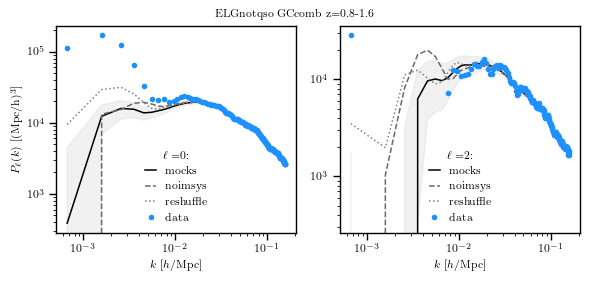

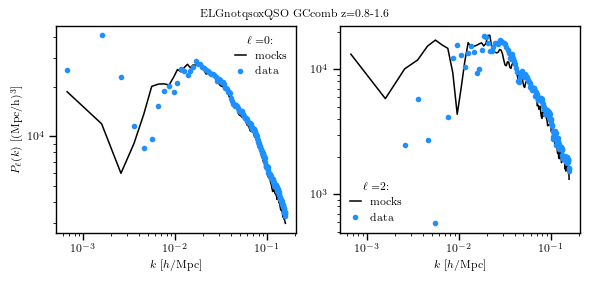

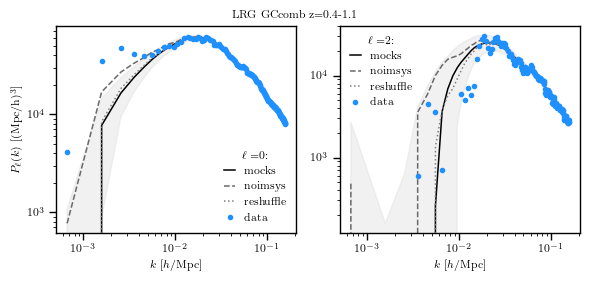

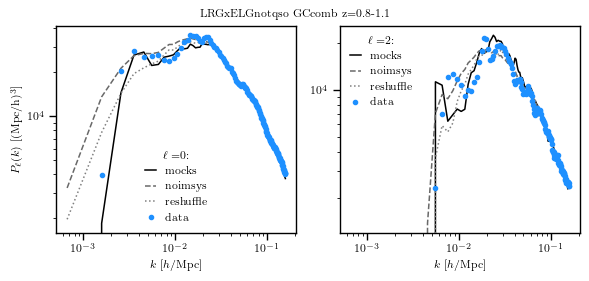

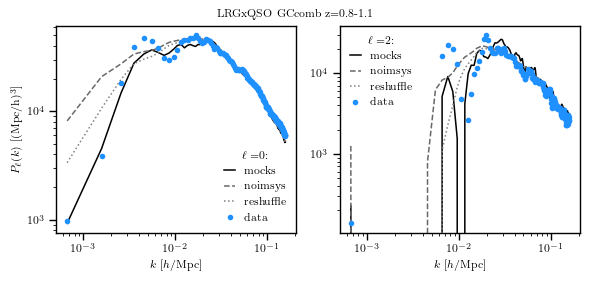

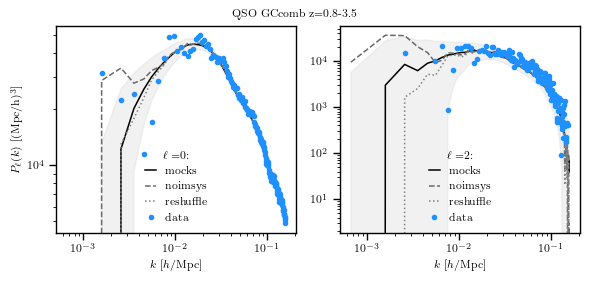

Figure sauvegardée: /Users/edmond/Work/desi-clustering/local_png/check_mocks_all_figures.pdf


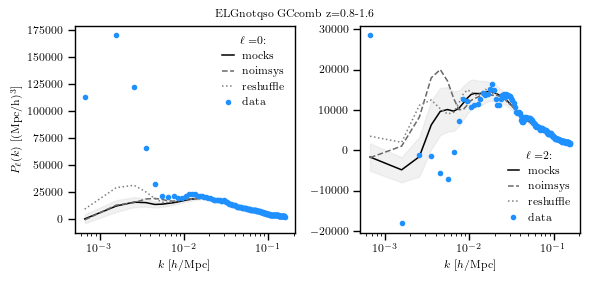

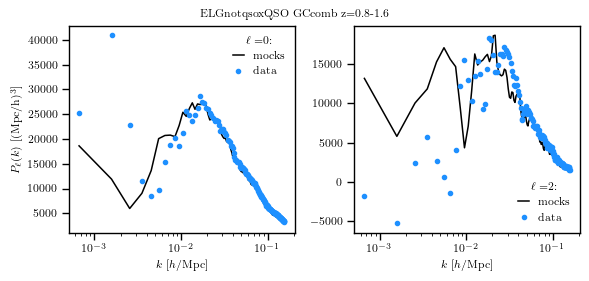

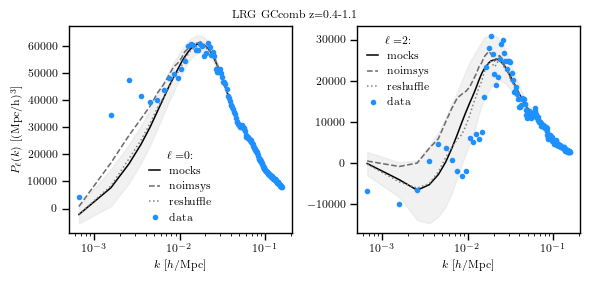

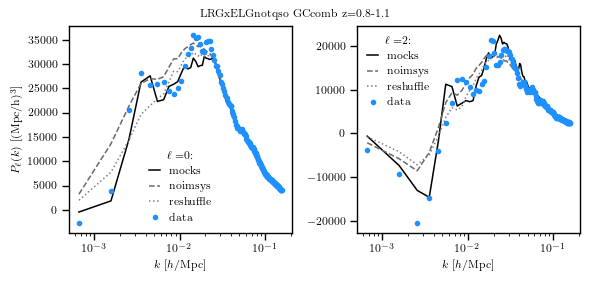

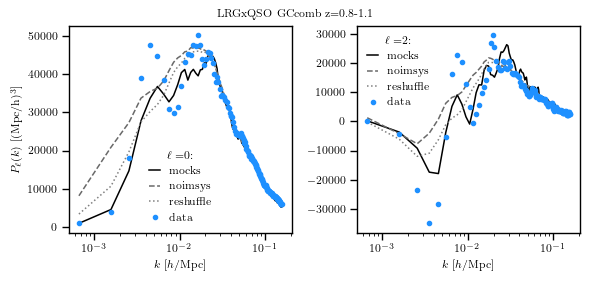

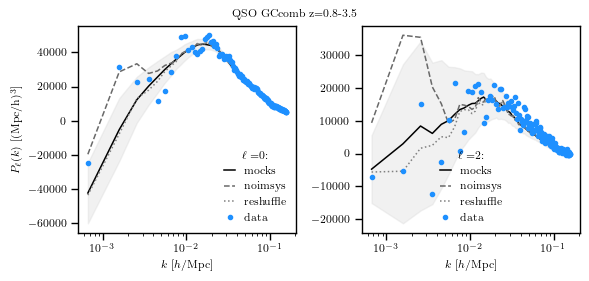

Figure sauvegardée: /Users/edmond/Work/desi-clustering/local_png/check_mocks_all_figures_linear.pdf


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from tools import read_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import lsstypes

plt.style.use('ec_style.mplstyle')   

data_dir = Path('/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/')

for logscale in [True, False]:

    if logscale:
        pdf_path = Path('fig/check_mocks_all_figures.pdf')
    else:
        pdf_path = Path('fig/check_mocks_all_figures_linear.pdf')

    with PdfPages(pdf_path) as pdf:
        for tracer in tracers_available:
            region = 'GCcomb'
            zrange = zranges_by_tracer.get(tracer, [])

            try:
                pk_data, _, _ = read_data(stats_dir=data_dir, tracer=tracer, zrange=zrange.split('-'), weight_type='default-fkp-oqe', region=region)

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
                fns = list(available[sel]['path'])

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe')
                fns_noimsys = list(available[sel]['path'])

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe_reshuffle')
                fns_reshuffle = list(available[sel]['path'])

                pks = [lsstypes.read(fn) for fn in fns]
                mean = lsstypes.mean(pks)

                fig = plt.figure(figsize=(6, 3))
                for ill, ell in enumerate([0, 2]):
                    ax = fig.add_subplot(1, 2, ill + 1)
                    k = mean.get(ell).k
                    mm = mean.get(ell).value()

                    if len(fns) > 1:
                        std = np.std([pk.get(ell).value() for pk in pks], axis=0)
                        ax.fill_between(k, mm - std, mm + std, color='lightgray', alpha=0.3)
                    else:
                        std = np.zeros_like(mm)
                    ax.plot(k, mm, c='black', label=f'mocks')

                    if len(fns_noimsys) > 0:
                        pk_noimsys = lsstypes.mean([lsstypes.read(fn) for fn in fns_noimsys])
                        ax.plot(k, pk_noimsys.get(ell).value(), c='dimgray', ls='--', label='noimsys')

                    if len(fns_reshuffle) > 0:
                        pk_reshuffle = lsstypes.mean([lsstypes.read(fn) for fn in fns_reshuffle])
                        ax.plot(k, pk_reshuffle.get(ell).value(), c='gray', ls=':', label='reshuffle')

                    ax.plot(k, pk_data.get(ell).value(), marker='o', ls='', c='dodgerblue', markersize=3, label='data')
                    # ax.errorbar(k, pk_data.get(ell).value(), yerr=std, fmt='o', c='black', markersize=2, label='data')


                    ax.set_xlabel(r'$k$ [$h/$Mpc]')
                    ax.set_xscale('log')
                    if logscale: ax.set_yscale('log')
                    if ill == 0:
                        ax.set_ylabel(r'$P_{\ell}(k)$ [$(\rm{Mpc}/h)^3$]')
                    ax.legend(title=rf'$\ell=${ell}:')

                fig.suptitle(f'{tracer} {region} z={zrange}', fontsize=8, y=0.92)
                fig.tight_layout()

                pdf.savefig(fig)   # <-- ajoute cette figure au PDF
                plt.show(fig)     # <-- évite d’accumuler la mémoire

            except Exception as e:
                print(f"Erreur pour {tracer}: {e}")

    print(f"Figure sauvegardée: {pdf_path.resolve()}")